# Counterfactual Generation via TabPFN as Energy-Based Model

Main idea adapted from TabPFGen: use frozen TabPFN outputs in the energy, but reformulated for counterfactual explanations.

External classifier agreement is mandatory (validity), while TabPFN provides the class-conditional plausibility term via p(y|x) ~ p(x|y).

**Counterfactual Energy:**
$$E(x \mid x_0, c') = \lambda_\text{val}[-\log p_\text{tab}(c'\mid x)] + \lambda_\text{clf}[-\log p_\text{clf}(c'\mid x)] + \lambda_{L_1} \|x - x_0\|_1 + \lambda_{L_2} \|x - x_0\|_2^2$$


In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tabpfn.scripts.transformer_prediction_interface import TabPFNClassifier
from tabpfn.counterfactual_ebm import generate_counterfactuals, EBMConfig, debug_tabpfn_gradient

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['figure.dpi'] = 100


## 1. Data & Models

In [2]:
X_raw, y = make_moons(n_samples=1200, noise=0.1, random_state=42)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42, stratify=y
)

# Min-max standardization to [0, 1] using train statistics only
X_min, X_max = X_train_raw.min(axis=0), X_train_raw.max(axis=0)
X_train = (X_train_raw - X_min) / (X_max - X_min)
X_test = (X_test_raw - X_min) / (X_max - X_min)

# TabPFN
tabpfn = TabPFNClassifier(device='cpu', N_ensemble_configurations=1)
tabpfn.fit(X_train, y_train)

# External classifier (mandatory in energy)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

clf_model = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 2))
opt = torch.optim.Adam(clf_model.parameters(), lr=1e-3)
for _ in range(500):
    opt.zero_grad()
    nn.functional.cross_entropy(clf_model(X_train_t), y_train_t).backward()
    opt.step()
clf_model.eval()

def clf_proba_fn(x_tensor):
    return torch.softmax(clf_model(x_tensor), dim=-1)

grad_debug = debug_tabpfn_gradient(tabpfn, X_test[:1], target_class=1 - int(y_test[0]))

print(f"TabPFN train acc: {(tabpfn.predict(X_train) == y_train).mean():.3f}")
print(f"TabPFN test acc:  {(tabpfn.predict(X_test) == y_test).mean():.3f}")
print(f"MLP train acc:    {(clf_model(X_train_t).argmax(1) == y_train_t).float().mean():.3f}")
print(f"MLP test acc:     {(clf_model(X_test_t).argmax(1) == y_test_t).float().mean():.3f}")
print(f"TabPFN grad ok:   {grad_debug['has_grad']}")
print(f"TabPFN grad norm: {grad_debug['grad_norm']:.6f}")


TabPFN train acc: 1.000
TabPFN test acc:  1.000
MLP train acc:    0.989
MLP test acc:     0.986
TabPFN grad ok:   True
TabPFN grad norm: 9.031098


## 2. Visualization helpers

In [3]:
def plot_decision_boundary(ax, model, X, resolution=200, alpha=0.3):
    """Plot decision boundary as background contour."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, probs, levels=np.linspace(0, 1, 11),
                cmap='RdBu_r', alpha=alpha)
    ax.contour(xx, yy, probs, levels=[0.5], colors='k', linewidths=1.5, linestyles='--')


def plot_counterfactuals(ax, x_0, x_cf, X, y, model, title=""):
    """Plot original points, counterfactuals, and arrows between them."""
    plot_decision_boundary(ax, model, X)
    # Training data
    ax.scatter(X[y==0, 0], X[y==0, 1], c='tab:blue', alpha=0.2, s=15, label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], c='tab:red', alpha=0.2, s=15, label='Class 1')
    # Original points
    ax.scatter(x_0[:, 0], x_0[:, 1], c='blue', s=80, edgecolors='k', zorder=5, label='Factual (x₀)')
    # Counterfactuals
    ax.scatter(x_cf[:, 0], x_cf[:, 1], c='red', s=80, marker='*', edgecolors='k', zorder=5, label='CF (x)')
    # Arrows
    for i in range(len(x_0)):
        ax.annotate('', xy=x_cf[i], xytext=x_0[i],
                     arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')

## 3. Generate counterfactuals with external MLP classifier


In [11]:
np.random.seed(0)
idx_0 = np.where(y_test == 0)[0]
chosen = np.random.choice(idx_0, size=5, replace=False)
x_0 = X_test[chosen]

config_cf = EBMConfig(
    lambda_val=2.0, lambda_clf=2, lambda_l1=1, lambda_l2=1,
    sgld_steps=500, sgld_lr=0.001, sgld_noise=0.1,
    tab_validity_thresh=0.5, clf_validity_thresh=0.5,
)

result_cf = generate_counterfactuals(
    x_0=x_0, target_class=1, tabpfn=tabpfn,
    clf_proba_fn=clf_proba_fn, config=config_cf, return_trajectory=True,
)

x_cf = result_cf['x_cf']
probs_tab = tabpfn.predict_proba(x_cf)
with torch.no_grad():
    probs_mlp = torch.softmax(clf_model(torch.tensor(x_cf, dtype=torch.float32)), dim=-1).numpy()
validity_tab = (probs_tab[:, 1] > 0.5).mean()
validity_mlp = (probs_mlp[:, 1] > 0.5).mean()
l2_cf = np.linalg.norm(x_cf - x_0, axis=1)

print(f"Validity (TabPFN): {validity_tab:.0%}")
print(f"Validity (MLP):    {validity_mlp:.0%}")
print(f"L2 distance: {l2_cf.mean():.3f} ± {l2_cf.std():.3f}")


Validity (TabPFN): 100%
Validity (MLP):    100%
L2 distance: 0.383 ± 0.122


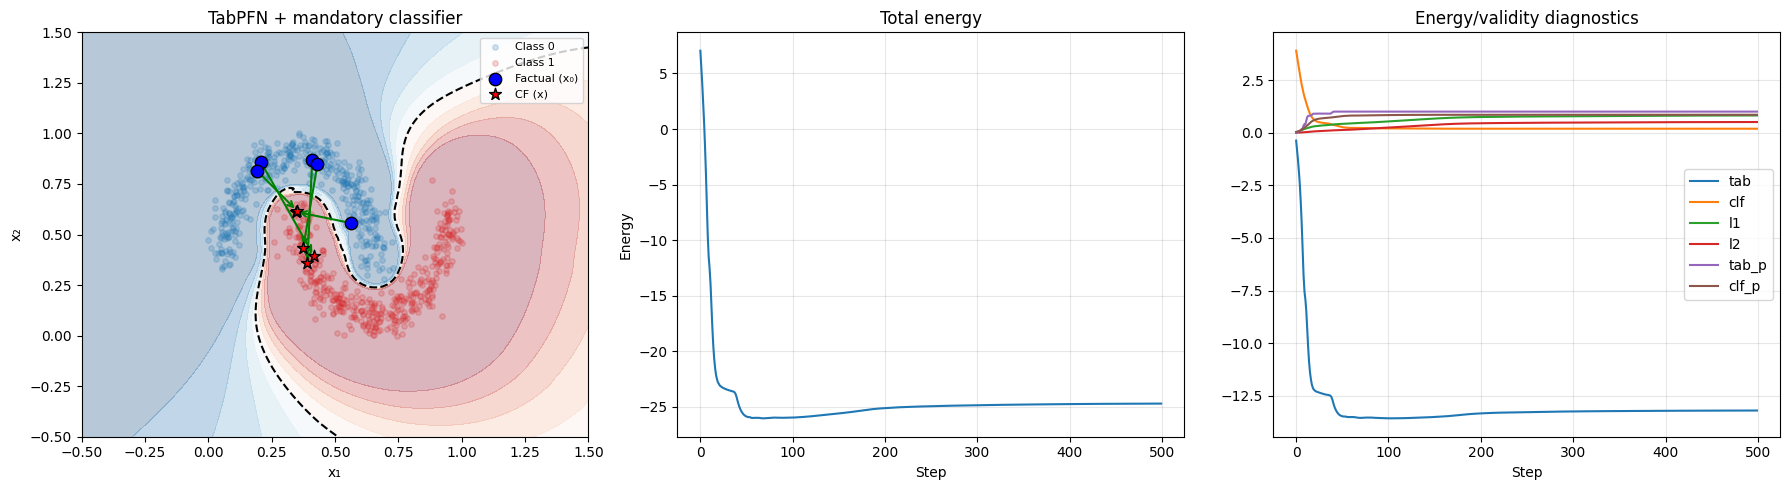

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_counterfactuals(axes[0], x_0, x_cf, X_train, y_train, tabpfn, title="TabPFN + mandatory classifier")

hist_cf = result_cf['energy_history']
axes[1].plot([h['total'] for h in hist_cf])
axes[1].set_xlabel('Step'); axes[1].set_ylabel('Energy'); axes[1].set_title('Total energy')
axes[1].grid(True, alpha=0.3)

for key in ['tab', 'clf', 'l1', 'l2', 'tab_p', 'clf_p']:
    vals = [h[key] for h in hist_cf]
    if max(abs(v) for v in vals) > 0:
        axes[2].plot(vals, label=key)
axes[2].set_xlabel('Step'); axes[2].set_title('Energy/validity diagnostics')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 4. Trajectories — SGLD optimization paths


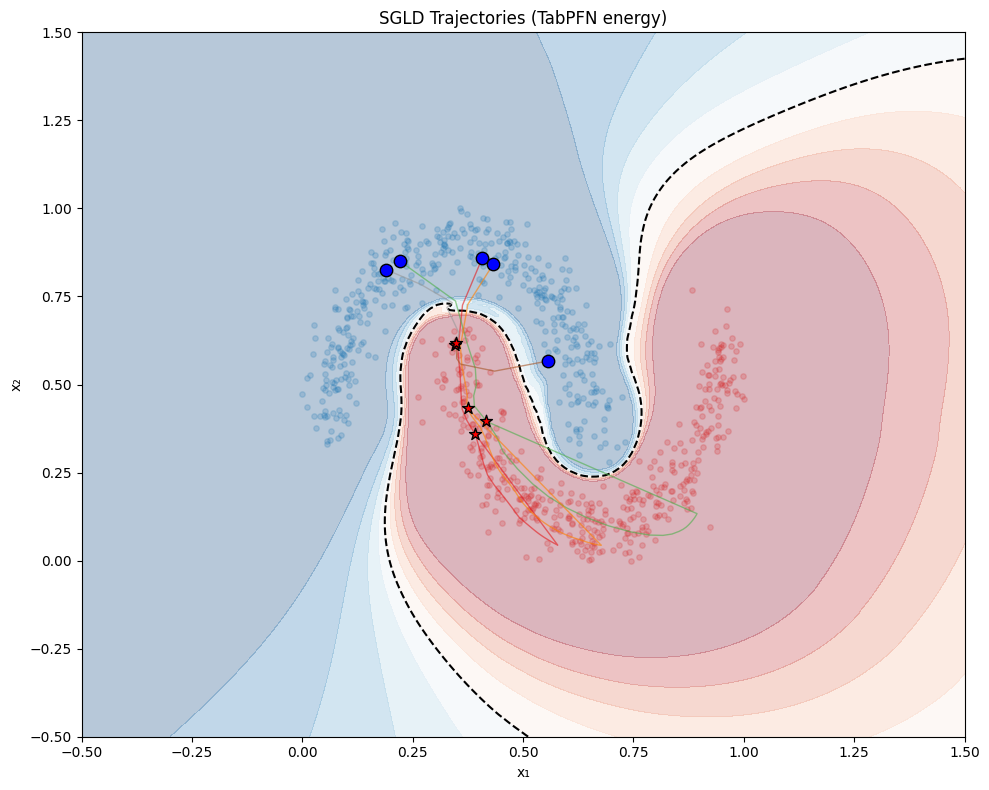

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_decision_boundary(ax, tabpfn, X_train)
ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='tab:blue', alpha=0.2, s=15)
ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='tab:red', alpha=0.2, s=15)

# Plot trajectories for TabPFN-energy result
traj = result_cf['trajectory']  # list of (n, d) arrays
colors = plt.cm.Set1(np.linspace(0, 1, len(x_0)))
for i in range(len(x_0)):
    path = np.array([t[i] for t in traj])
    ax.plot(path[:, 0], path[:, 1], '-', color=colors[i], alpha=0.6, linewidth=1)
    ax.scatter(path[0, 0], path[0, 1], c='blue', s=80, edgecolors='k', zorder=5)
    ax.scatter(result_cf['x_cf'][i, 0], result_cf['x_cf'][i, 1], c='red', s=80, marker='*', edgecolors='k', zorder=6)

ax.set_title('SGLD Trajectories (TabPFN energy)')
ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
plt.tight_layout()
plt.show()


## 5. Both directions — class 0→1 and class 1→0


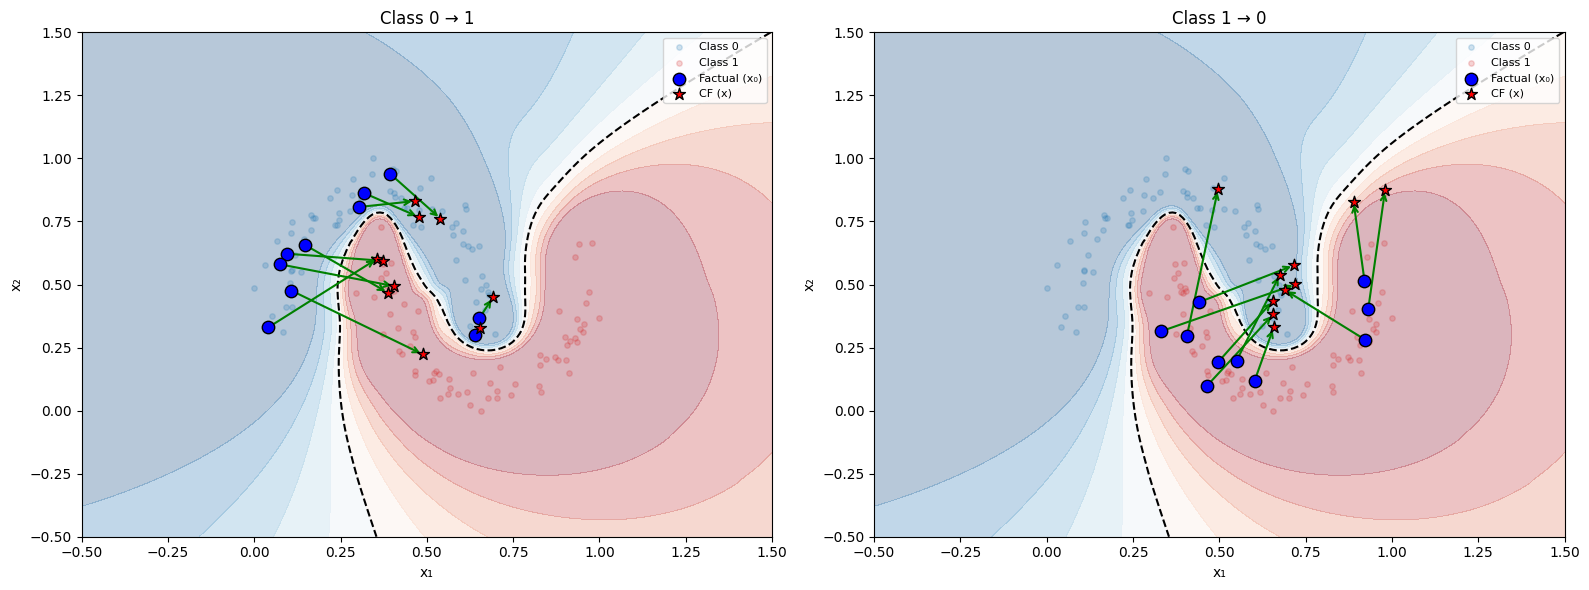

Class 1→0 validity (TabPFN): 80%
Class 1→0 validity (MLP):    90%
Class 1→0 L2: 0.364


In [7]:
idx_1 = np.where(y_test == 1)[0]
chosen_1 = np.random.choice(idx_1, size=10, replace=False)
x_0_class1 = X_test[chosen_1]

config = EBMConfig(
    lambda_val=0.2, lambda_clf=5.0, lambda_l1=3.0, lambda_l2=3.0,
    sgld_steps=400, sgld_lr=0.001, sgld_noise=0.05,
    tab_validity_thresh=0.5, clf_validity_thresh=0.5,
)

result_1to0 = generate_counterfactuals(
    x_0=x_0_class1, target_class=0, tabpfn=tabpfn,
    clf_proba_fn=clf_proba_fn, config=config,
    feature_min=0.0, feature_max=1.0,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_counterfactuals(axes[0], x_0, x_cf, X_train, y_train, tabpfn, title="Class 0 → 1")
plot_counterfactuals(axes[1], x_0_class1, result_1to0['x_cf'], X_train, y_train, tabpfn, title="Class 1 → 0")
plt.tight_layout()
plt.show()

probs_1to0 = tabpfn.predict_proba(result_1to0['x_cf'])
with torch.no_grad():
    probs_1to0_mlp = torch.softmax(clf_model(torch.tensor(result_1to0['x_cf'], dtype=torch.float32)), dim=-1).numpy()
print(f"Class 1→0 validity (TabPFN): {(probs_1to0[:, 0] > 0.5).mean():.0%}")
print(f"Class 1→0 validity (MLP):    {(probs_1to0_mlp[:, 0] > 0.5).mean():.0%}")
print(f"Class 1→0 L2: {np.linalg.norm(result_1to0['x_cf'] - x_0_class1, axis=1).mean():.3f}")
